# Linear Associator as a Classifier

Using a linear associator as a classifier: mapping a 5-dimensional feature vector (wrap, frequency, ratio, color, name pattern) to a 7-dimensional output encoding origin and action, including feature selection and handling of missing data.

## Code

In [61]:
import numpy as np

In [62]:
def load_ship_data(file_path, training_stats=None):
    origins = {"Klingon": 0, "Romulan": 1, "Antarean": 2, "Federation": 3}
    actions = {"Hostile": 4, "Alert": 5, "Friendly": 6}

    data_list = []

    with open(file_path, 'r') as f:
        for line in f:
            parts = [p.strip() for p in line.split('\t')]

            if len(parts) < 6:
                continue

            # extract features
            name = parts[0]
            # parts[1] is origin
            warp = parts[2]
            freq = parts[3]
            color = parts[4]
            ratio = parts[5]

            # extract numerical values and handle missing data
            def parse_num(val):
                try: return float(val)
                except: return None

            row_features = {
                "name": name,
                "warp": parse_num(warp),
                "freq": parse_num(freq),
                "ratio": parse_num(ratio),
                "color": color
            }

            # check if traindata, parts[1] == '?' then traindata
            if parts[1] != '?':
                if len(parts) < 7:
                    continue
                origin_label = parts[1]
                action_label = parts[6]
                g_target = np.zeros(7)
                g_target[origins[origin_label]] = 1
                g_target[actions[action_label]] = 1
                row_features["g_target"] = g_target

            data_list.append(row_features)

    return data_list

In [63]:
train_data = load_ship_data('traindata.txt')

# extract warp, freq, ratio for stats (mean, std)
raw_nums = np.array([[d['warp'], d['freq'], d['ratio']] for d in train_data])
means = np.nanmean(raw_nums, axis=0)
stds = np.nanstd(raw_nums, axis=0)

print(f"Stats calculated from traindata.txt:")
print(f'        Warp.   Freq.   Ratio')
print(f"Means: {means}\nStds: {stds}")

Stats calculated from traindata.txt:
        Warp.   Freq.   Ratio
Means: [   6.92  1011.435    1.92 ]
Stds: [ 0.31874755 36.30459027  0.67867518]


In [64]:
# g-vector indices: 0-3 = Origin, 4-6 = Action
origin_map = {"Klingon": 0, "Romulan": 1, "Antarean": 2, "Federation": 3}
action_map = {"Hostile": 4, "Alert": 5, "Friendly": 6}

In [65]:
def generate_matrices(data_list, training_means, training_stds, is_training=True):
    f_list = []
    g_list = []

    for d in data_list:
        # numerical values
        # missing data dealing strat: replacing None with 0.0 (the mean)
        f_warp = (d['warp'] - training_means[0]) / training_stds[0] if d['warp'] is not None else 0.0
        f_freq = (d['freq'] - training_means[1]) / training_stds[1] if d['freq'] is not None else 0.0
        f_ratio = (d['ratio'] - training_means[2]) / training_stds[2] if d['ratio'] is not None else 0.0

        # text features
        # color: bipolar encoding (1 for dark, -1 for light)
        # missing data dealing strat: setting it as 0.0
        color = d['color'].lower()
        if any(x in color for x in ['black', 'dark']):
            f_color = 1.0
        elif any(x in color for x in ['white', 'light']):
            f_color = -1.0
        else:
            f_color = 0.0

        # name: bipolar encoding (1 for (A, E, digits), -1 for rest)
        # missing data dealing strat: setting it as 0.0
        name = d['name'].upper()
        if any(x in name for x in ['A', 'E']) or any(c.isdigit() for c in name):
            f_name = 1.0
        elif any(x in name for x in ['G', 'T', 'B']): #, 'L'
            f_name = -1.0
        else:
            f_name = 0.0

        f_list.append([f_warp, f_freq, f_ratio, f_color, f_name])

        # extract g (target vector)
        if is_training and 'g_target' in d:
            g_list.append(d['g_target'])

    return np.array(f_list), np.array(g_list)

In [66]:
# generate f, g matrices
f_train, g_train = generate_matrices(train_data, means, stds, is_training=True)

print(f"Matrix f_train shape: {f_train.shape}") # Should be (20, 5)
print(f"Matrix g_train shape: {g_train.shape}") # Should be (20, 7)

Matrix f_train shape: (20, 5)
Matrix g_train shape: (20, 7)


The dimensions of f and g vectors are written above. The dimension of the f vector is 5, and the dimension of the g vector is 7. 20 is the number of the data.

The dimensions of the f vector is the input features: wrap, frequency, ratio, color, and name pattern.

The dimensions of the g vector is the output slots: 4 of origins and 3 of actions.

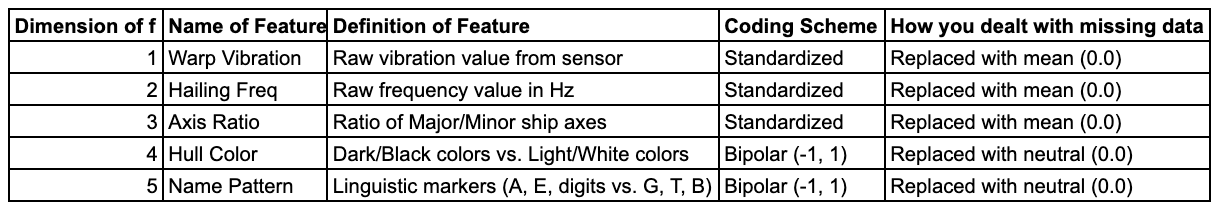

In [67]:
# TRAINING
# initialization
F_DIM = f_train.shape[1] # 5 features: Warp, Freq, Ratio, Dark, Name
G_DIM = g_train.shape[1] # 7 outputs: 4 Origin, 3 Action

# initialize weight matrix with zeros
weights = np.zeros((G_DIM, F_DIM))

learning_rate = 0.01
convergence_criterion = 0.001
max_trials = 5000

# learning process
for trial in range(max_trials):
    total_squared_error = 0

    for i in range(len(f_train)):
        f = f_train[i].reshape(-1, 1)
        g_target = g_train[i].reshape(-1, 1)

        # Linear Activation: g_actual = W * f
        g_actual = np.dot(weights, f)

        # Delta Rule: W_new = W_old + eta * (g_target - g_actual) * f_T
        error = g_target - g_actual
        weights += learning_rate * np.dot(error, f.T)

        total_squared_error += np.sum(error**2)

    if total_squared_error < convergence_criterion:
        print(f"Convergence reached at trial {trial}")
        break
else:
    print("Reached max trials without full convergence.")

Reached max trials without full convergence.


In [59]:
# 3. TEST CLASSIFICATION
test_data_raw = load_ship_data('testdata.txt')
f_test, _ = generate_matrices(test_data_raw, means, stds, is_training=False)

origins = ["Klingon", "Romulan", "Antarean", "Federation"]
actions = ["Hostile", "Alert", "Friendly"]

print(f"\n{'Ship #':<8} | {'Origin Prediction':<18} | {'Action Prediction'}")
print("-" * 55)

for i, f_vec in enumerate(f_test):
    g_out = np.dot(weights, f_vec.reshape(-1, 1))

    origin_idx = np.argmax(g_out[0:4])
    action_idx = np.argmax(g_out[4:7])

    print(f"Ship {i+1:<4} | {origins[origin_idx]:<18} | {actions[action_idx]}")


Ship #   | Origin Prediction  | Action Prediction
-------------------------------------------------------
Ship 1    | Romulan            | Alert
Ship 2    | Federation         | Friendly
Ship 3    | Federation         | Friendly
Ship 4    | Federation         | Friendly
Ship 5    | Klingon            | Hostile
Ship 6    | Romulan            | Alert
Ship 7    | Antarean           | Alert
Ship 8    | Romulan            | Alert
Ship 9    | Klingon            | Hostile
Ship 10   | Federation         | Friendly
Ship 11   | Klingon            | Hostile
Ship 12   | Klingon            | Hostile
Ship 13   | Antarean           | Friendly
Ship 14   | Federation         | Friendly
Ship 15   | Romulan            | Alert
Ship 16   | Romulan            | Alert
Ship 17   | Antarean           | Friendly
Ship 18   | Federation         | Friendly
Ship 19   | Antarean           | Friendly
Ship 20   | Federation         | Friendly


The output classification result is printed out in the cell above:

## Write-up

Dimensions of f and g vectors, tables regarding features and missing data dealing strategy, output classification is included in the CODE section.

_________________________

I decided to use all the features excluding the origin and action for the f vector. By analyzing it with human ability, I found out all features have information worthy enough to be an input. For the numeric features, I standardized it, and for the other, I converted it into a bipolar value.

For the g vector, I set 0 to 3 as each of the origins, in the order it was listed in the traindata, and from 4 to 6 as the actions from hostile, alert, to friendly.

For the missing data, I set them to 0 for all cases as I thought it would be the best to make them neutral since we do not know the answer to it. Also, by setting it at 0, it would have minimal effect to the result.

The system was trained using the Widrow-Hoff to minimize the errors. The parameters were learning constant as 0.01, convergence criterion as 0.001, and number of trials as 5000. I have tried modifying the parameters, but they gave the same answers, so I assume it is because of a very small data size. THe error correction was done by the delta rule. After getting the error for each trial, it was projected back to the weights.